In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU!")


GPU: Tesla T4


In [ ]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow tqdm opencv-python-headless


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
Base =  "/content/drive/MyDrive/disease_data"
print("brain_mri:", "Yes" if os.path.exists(f"{Base}/brain_mri") else "NO")
for split in ["Training","Testing"]:
    for cls in ["glioma","meningioma","notumor","pituitary"]:
        p = f"{Base}/brain_mri/{split}/{cls}"
        if os.path.exists(p):
            print(f"  {split}/{cls}: {len(os.listdir(p))}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
brain_mri: Yes
  Training/glioma: 1400
  Training/meningioma: 1400
  Training/notumor: 1400
  Training/pituitary: 1400
  Testing/glioma: 400
  Testing/meningioma: 400
  Testing/notumor: 400
  Testing/pituitary: 400


In [ ]:
import os, random, shutil, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import cv2, torch
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Brain Model

In [ ]:
Class_Map = {"glioma":"Glioma","meningioma":"Meningioma","notumor":"No_Tumor","pituitary":"Pituitary"}
Classes   = ["Glioma","Meningioma","No_Tumor","Pituitary"]
Base_Out  = "/content/brain_combined"
for cls in Classes: os.makedirs(f"{Base_Out}/{cls}", exist_ok=True)

total = 0
for split in ["Training","Testing"]:
    for raw, clean in Class_Map.items():
        src = f"{Base}/brain_mri/{split}/{raw}"
        if not os.path.exists(src): continue
        files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for i, f in enumerate(tqdm(files, desc=f"  {split}/{raw}", leave=False)):
          shutil.copy2(os.path.join(src,f), f"{Base_Out}/{clean}/{split}_{raw}_{i:05d}{os.path.splitext(f)[1]}")
          total += 1

print(f"Total: {total}")
for cls in Classes: print(f"  {cls}: {len(os.listdir(f'{Base_Out}/{cls}'))}")


Total: 7200
  Glioma: 1800
  Meningioma: 1800
  No_Tumor: 1800
  Pituitary: 1800


In [ ]:
class SimpleDataset(Dataset):
    def __init__(self,root, transform=None):
        self.samples = []
        self.transformer = transform
        self.classes = sorted(os.listdir(root))
        self.class_to_idx={c:i for i,c in enumerate(self.classes)}
        for cls in self.classes:
          d=os.path.join(root,cls)
          if not os.path.isdir(d):continue
          for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f), self.class_to_idx[cls]))

    def __len__(self):
      return len(self.samples)
    def __getitem__(self, idx):
      p,l = self.samples[idx]
      try:
        img = Image.open(p).convert('RGB')
      except:
        img = Image.new('RGB',(224,224),0)
      if self.transformer: img=self.transformer(img)
      return img,l

In [ ]:
train_tf = transforms.Compose([transforms.Resize((224,224)),transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),transforms.ColorJitter(0.2,0.3),
    transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

full_ds=SimpleDataset(Base_Out,transform=train_tf); class_names=full_ds.classes
val_size=int(0.15*len(full_ds)); train_size=len(full_ds)-val_size
train_ds,val_ds=torch.utils.data.random_split(full_ds,[train_size,val_size],generator=torch.Generator().manual_seed(42))
val_ds.dataset=SimpleDataset(Base_Out,transform=val_tf)
train_loader=DataLoader(train_ds,batch_size=32,shuffle=True,num_workers=2,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=32,shuffle=False,num_workers=2,pin_memory=True)
print(f"Train:{len(train_ds)} Val:{len(val_ds)}")

Train:6120 Val:1080


In [ ]:
labels_all=[full_ds.samples[i][1] for i in range(len(full_ds))]; counts=Counter(labels_all)
class_weights=torch.tensor([sum(counts.values())/(len(class_names)*counts[i]) for i in range(len(class_names))],dtype=torch.float).to(device)
model=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for n,p in model.named_parameters():
    if "layer4" not in n and "fc" not in n: p.requires_grad=False
model.fc=nn.Sequential(nn.Dropout(0.4),nn.Linear(model.fc.in_features,512),nn.ReLU(),nn.Dropout(0.3),nn.Linear(512,4))
model=model.to(device)
criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=optim.AdamW(filter(lambda p:p.requires_grad,model.parameters()),lr=1e-4,weight_decay=1e-4)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10,eta_min=1e-6)

In [ ]:
def train_epoch(model,loader,criterion,optimizer):
    model.train(); tl,correct,total=0,0,0
    for imgs,labels in tqdm(loader,desc="  Train",leave=False):
        imgs,labels=imgs.to(device),labels.to(device); optimizer.zero_grad()
        out=model(imgs); loss=criterion(out,labels); loss.backward(); optimizer.step()
        tl+=loss.item(); correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
    return tl/len(loader),correct/total

def val_epoch(model,loader,criterion):
    model.eval(); tl,correct,total=0,0,0
    with torch.no_grad():
        for imgs,labels in tqdm(loader,desc="  Val  ",leave=False):
            imgs,labels=imgs.to(device),labels.to(device); out=model(imgs)
            tl+=criterion(out,labels).item(); correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
    return tl/len(loader),correct/total

In [ ]:
best_acc=0.0; BEST="/content/brain_best.pth"
history={k:[] for k in ["train_loss","val_loss","train_acc","val_acc"]}
print("PHASE 1")
for epoch in range(1,11):
    tl,ta=train_epoch(model,train_loader,criterion,optimizer)
    vl,va=val_epoch(model,val_loader,criterion); scheduler.step()
    for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
    flag=""
    if va>best_acc: best_acc=va; torch.save(model.state_dict(),BEST); flag="  ← best"
    print(f"Epoch {epoch:02d}/10 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

PHASE 1


Epoch 01/10 | Train 82.11% | Val 93.24%  ← best


Epoch 02/10 | Train 93.51% | Val 96.11%  ← best


Epoch 03/10 | Train 95.56% | Val 96.85%  ← best


Epoch 04/10 | Train 96.68% | Val 97.13%  ← best


...

Epoch 06/10 | Train 98.19% | Val 98.15%  ← best


Epoch 07/10 | Train 98.25% | Val 98.52%  ← best


Epoch 08/10 | Train 98.56% | Val 98.52%


Epoch 09/10 | Train 98.86% | Val 98.52%


Epoch 10/10 | Train 98.92% | Val 98.43%


In [ ]:
model.load_state_dict(torch.load(BEST))
for p in model.parameters(): p.requires_grad=True
opt2=optim.AdamW(model.parameters(),lr=3e-5,weight_decay=1e-4)
sch2=optim.lr_scheduler.CosineAnnealingLR(opt2,T_max=5,eta_min=1e-7)
print("PHASE 2")
for epoch in range(1,6):
    tl,ta=train_epoch(model,train_loader,criterion,opt2)
    vl,va=val_epoch(model,val_loader,criterion); sch2.step()
    for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
    flag=""
    if va>best_acc: best_acc=va; torch.save(model.state_dict(),BEST); flag="  ← best"
    print(f"Epoch {epoch:02d}/05 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")
print(f"Best: {best_acc*100:.2f}%")

PHASE 2


Epoch 01/05 | Train 98.20% | Val 98.43%


Epoch 02/05 | Train 98.91% | Val 97.96%


Epoch 03/05 | Train 98.94% | Val 98.61%  ← best


Epoch 04/05 | Train 99.13% | Val 98.80%  ← best


Epoch 05/05 | Train 99.49% | Val 98.70%
Best: 98.80%


In [ ]:
torch.save(model.state_dict(), "/content/brain_model.pth")
metadata={"model_name":"ResNet50 Brain Tumor","num_classes":4,"classes":class_names,
    "class_to_idx":{c:i for i,c in enumerate(class_names)},"input_size":[224,224],
    "normalize_mean":[0.485,0.456,0.406],"normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_acc*100,2),"scan_type":"MRI",
    "disease_info":{
        "Glioma":{"description":"Brain/spinal cord tumor from glial cells","symptoms":["Headache","Seizures","Memory loss"],"treatment":"Surgery, radiation, chemo","risk":"High","emergency":False},
        "Meningioma":{"description":"Tumor from brain membranes","symptoms":["Headaches","Limb weakness","Seizures"],"treatment":"Observation or surgery","risk":"Usually benign","emergency":False},
        "No_Tumor":{"description":"No tumor detected","symptoms":["None"],"treatment":"None","risk":"None","emergency":False},
        "Pituitary":{"description":"Pituitary gland tumor","symptoms":["Headaches","Vision changes","Hormonal issues"],"treatment":"Surgery or medication","risk":"Moderate","emergency":False},
    }}
with open("/content/brain_metadata.json","w") as f: json.dump(metadata,f,indent=2)
SAVE_DIR="/content/drive/MyDrive/medical_ai_models"; os.makedirs(SAVE_DIR,exist_ok=True)
for fp in ["/content/brain_model.pth","/content/brain_metadata.json"]:
    shutil.copy2(fp, os.path.join(SAVE_DIR,os.path.basename(fp))); print(f"  Saved: {os.path.basename(fp)}")
print(f"Brain model done — {best_acc*100:.2f}%")

  Saved: brain_model.pth
  Saved: brain_metadata.json
Brain model done — 98.80%


Eye model Train


In [ ]:
EYE_BASE    = f"{Base}/eye"
EYE_DISEASE_OUT = "/content/eye_disease_combined"

# Same mapping as organ v2 but for DISEASE classification
EYE_CLASS_MAP = {
    "Eye_Normal": [
        "0.0.Normal",
    ],
    "Eye_DR": [
        "0.3.DR1", "1.0.DR2", "1.1.DR3",
        "29.0.Blur fundus without PDR",
        "29.1.Blur fundus with suspected PDR",
    ],
    "Eye_Glaucoma": [
        "10.0.Possible glaucoma",
        "0.2.Large optic cup",
        "10.1.Optic atrophy",
    ],
    "Eye_Maculopathy": [
        "6.Maculopathy",
        "20.Massive hard exudates",
        "5.0.CSCR",
        "5.1.VKH disease",
        "21.Yellow-white spots-flecks",
    ],
    "Eye_Vascular": [
        "2.0.BRVO", "2.1.CRVO", "3.RAO",
        "23.Vessel tortuosity",
        "25.Preretinal hemorrhage",
    ],
    "Eye_Degeneration": [
        "15.0.Retinitis pigmentosa",
        "9.Pathological myopia",
        "4.Rhegmatogenous RD",
        "15.1.Bietti crystalline dystrophy",
        "16.Peripheral retinal degeneration and break",
    ],
    "Eye_Other": [
        "7.ERM", "8.MH",
        "11.Severe hypertensive retinopathy",
        "12.Disc swelling and elevation",
        "13.Dragged Disc",
        "14.Congenital disc abnormality",
        "17.Myelinated nerve fiber",
        "18.Vitreous particles",
        "19.Fundus neoplasm",
        "22.Cotton-wool spots",
        "24.Chorioretinal atrophy-coloboma",
        "26.Fibrosis",
        "0.1.Tessellated fundus",
    ],
}

EYE_OCT_FOLDERS    = ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"]
EYE_CORNEA_FOLDERS = ["Cornea_Ulcers", "Corneal_Ulcers_Agumentation"]
EYE_DISEASE_CLASSES = sorted(list(EYE_CLASS_MAP.keys()) + ["Eye_OCT", "Eye_Cornea"])

for cls in EYE_DISEASE_CLASSES:
    os.makedirs(f"{EYE_DISEASE_OUT}/{cls}", exist_ok=True)

print("Copying Eye Disease images...\n")
total_eye = 0

# ── Top-level folders ─────────────────────────────────────────
for eye_class, source_folders in EYE_CLASS_MAP.items():
    class_count = 0
    for folder in source_folders:
        src = os.path.join(EYE_BASE, folder)
        if not os.path.exists(src):
            continue
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # Use more images for disease classifier than organ classifier
        files = files[:500]
        tag   = folder.replace(" ", "_").replace(".", "")
        for i, f in enumerate(tqdm(files, desc=f"  {folder[:35]}", leave=False)):
            dest = f"{EYE_DISEASE_OUT}/{eye_class}/{tag}_{i:05d}{os.path.splitext(f)[1]}"
            shutil.copy2(os.path.join(src, f), dest)
            class_count += 1
            total_eye   += 1
    if class_count > 0:
        print(f"  {eye_class}: {class_count}")

# ── OCT images from ROFT/Retinal OCT/ ────────────────────────
oct_base  = os.path.join(EYE_BASE, "ROFT", "Retinal OCT")
oct_count = 0
if os.path.exists(oct_base):
    for oct_folder in EYE_OCT_FOLDERS:
        src = os.path.join(oct_base, oct_folder)
        if not os.path.exists(src):
            continue
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        files = files[:300]
        for i, f in enumerate(tqdm(files, desc=f"  OCT/{oct_folder}", leave=False)):
            dest = f"{EYE_DISEASE_OUT}/Eye_OCT/oct_{oct_folder}_{i:05d}{os.path.splitext(f)[1]}"
            shutil.copy2(os.path.join(src, f), dest)
            oct_count += 1
            total_eye += 1
    print(f"  Eye_OCT: {oct_count}")

# ── Cornea from ROFT/ ─────────────────────────────────────────
cornea_base  = os.path.join(EYE_BASE, "ROFT")
cornea_count = 0
if os.path.exists(cornea_base):
    for cf in EYE_CORNEA_FOLDERS:
        src = os.path.join(cornea_base, cf)
        if not os.path.exists(src):
            continue
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        files = files[:400]
        for i, f in enumerate(tqdm(files, desc=f"  Cornea/{cf}", leave=False)):
            dest = f"{EYE_DISEASE_OUT}/Eye_Cornea/cornea_{cf}_{i:05d}{os.path.splitext(f)[1]}"
            shutil.copy2(os.path.join(src, f), dest)
            cornea_count += 1
            total_eye    += 1
    print(f"  Eye_Cornea: {cornea_count}")

print(f"\nTotal: {total_eye} | Classes: {len(EYE_DISEASE_CLASSES)}")
print("\nFull breakdown:")
for cls in EYE_DISEASE_CLASSES:
    p = f"{EYE_DISEASE_OUT}/{cls}"
    if os.path.exists(p):
        print(f"  {cls:25s}: {len(os.listdir(p))}")

Copying Eye Disease images...



  Eye_Normal: 38


  Eye_DR: 262


  Eye_Glaucoma: 75


  Eye_Maculopathy: 144


  Eye_Vascular: 106


  Eye_Degeneration: 155


  Eye_Other: 178


  Eye_OCT: 1101


  Eye_Cornea: 800

Total: 2859 | Classes: 9

Full breakdown:
  Eye_Cornea               : 800
  Eye_DR                   : 262
  Eye_Degeneration         : 155
  Eye_Glaucoma             : 75
  Eye_Maculopathy          : 144
  Eye_Normal               : 38
  Eye_OCT                  : 1101
  Eye_Other                : 178
  Eye_Vascular             : 106


In [ ]:
full_eye    = SimpleDataset(EYE_DISEASE_OUT, transform=train_tf)
eye_classes = full_eye.classes
val_size    = int(0.15 * len(full_eye))
train_size  = len(full_eye) - val_size

tr_eye, vl_eye = torch.utils.data.random_split(
    full_eye, [train_size, val_size],
    generator=torch.Generator().manual_seed(42))
vl_eye.dataset = SimpleDataset(EYE_DISEASE_OUT, transform=val_tf)

tr_eye_loader = DataLoader(tr_eye, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl_eye_loader = DataLoader(vl_eye, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Eye — Classes: {len(eye_classes)} | Train: {len(tr_eye)} | Val: {len(vl_eye)}")
print(f"Classes: {eye_classes}")

Eye — Classes: 9 | Train: 2431 | Val: 428
Classes: ['Eye_Cornea', 'Eye_DR', 'Eye_Degeneration', 'Eye_Glaucoma', 'Eye_Maculopathy', 'Eye_Normal', 'Eye_OCT', 'Eye_Other', 'Eye_Vascular']


In [ ]:
eye_counts  = Counter([full_eye.samples[i][1] for i in range(len(full_eye))])
eye_weights = torch.tensor(
    [sum(eye_counts.values()) / (len(eye_classes) * eye_counts[i])
     for i in range(len(eye_classes))],
    dtype=torch.float).to(device)

print("Eye class weights (handling imbalance):")
for n, w in zip(eye_classes, eye_weights.cpu().numpy()):
    print(f"  {n:25s}: {w:.3f}")

eye_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for n, p in eye_model.named_parameters():
    if "layer4" not in n and "fc" not in n:
        p.requires_grad = False
eye_model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(eye_model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(eye_classes))
)
eye_model   = eye_model.to(device)
eye_crit    = nn.CrossEntropyLoss(weight=eye_weights)
eye_opt     = optim.AdamW(filter(lambda p: p.requires_grad, eye_model.parameters()),
                           lr=1e-4, weight_decay=1e-4)
eye_sch     = optim.lr_scheduler.CosineAnnealingLR(eye_opt, T_max=10, eta_min=1e-6)

trainable = sum(p.numel() for p in eye_model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Eye class weights (handling imbalance):
  Eye_Cornea               : 0.397
  Eye_DR                   : 1.212
  Eye_Degeneration         : 2.049
  Eye_Glaucoma             : 4.236
  Eye_Maculopathy          : 2.206
  Eye_Normal               : 8.360
  Eye_OCT                  : 0.289
  Eye_Other                : 1.785
  Eye_Vascular             : 2.997
Trainable params: 16,018,441


In [ ]:
best_eye =0.0
BEST_EYE    = "/content/eye_best.pth"
eye_history = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc"]}

print("=" * 55)
print("EYE — PHASE 1 (frozen backbone)")
print("=" * 55)

for epoch in range(1, 11):
    tl, ta = train_epoch(eye_model, tr_eye_loader, eye_crit, eye_opt)
    vl, va = val_epoch(eye_model,   vl_eye_loader, eye_crit)
    eye_sch.step()
    for k, v in zip(eye_history, [tl, vl, ta, va]):
        eye_history[k].append(v)
    flag = ""
    if va > best_eye:
        best_eye = va
        torch.save(eye_model.state_dict(), BEST_EYE)
        flag = "  ← best"
    print(f"Epoch {epoch:02d}/10 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

print(f"\nPhase 1 best: {best_eye*100:.2f}%")

EYE — PHASE 1 (frozen backbone)


Epoch 01/10 | Train 73.06% | Val 84.35%  ← best


Epoch 02/10 | Train 86.06% | Val 89.02%  ← best


Epoch 03/10 | Train 90.25% | Val 91.59%  ← best


Epoch 04/10 | Train 92.18% | Val 93.93%  ← best


...

Epoch 06/10 | Train 96.22% | Val 95.33%  ← best


Epoch 07/10 | Train 97.04% | Val 95.56%  ← best


Epoch 08/10 | Train 97.90% | Val 95.79%  ← best


Epoch 09/10 | Train 97.94% | Val 96.26%  ← best


Epoch 10/10 | Train 98.03% | Val 96.03%

Phase 1 best: 96.26%


In [ ]:
eye_model.load_state_dict(torch.load(BEST_EYE))
for p in eye_model.parameters():
    p.requires_grad = True

eye_opt2 = optim.AdamW(eye_model.parameters(), lr=3e-5, weight_decay=1e-4)
eye_sch2 = optim.lr_scheduler.CosineAnnealingLR(eye_opt2, T_max=5, eta_min=1e-7)

print("=" * 55)
print("EYE — PHASE 2 (full fine-tuning)")
print("=" * 55)

for epoch in range(1, 6):
    tl, ta = train_epoch(eye_model, tr_eye_loader, eye_crit, eye_opt2)
    vl, va = val_epoch(eye_model,   vl_eye_loader, eye_crit)
    eye_sch2.step()
    for k, v in zip(eye_history, [tl, vl, ta, va]):
        eye_history[k].append(v)
    flag = ""
    if va > best_eye:
        best_eye = va
        torch.save(eye_model.state_dict(), BEST_EYE)
        flag = "  ← best"
    print(f"Epoch {epoch:02d}/05 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

print(f"\nFinal best: {best_eye*100:.2f}%")

EYE — PHASE 2 (full fine-tuning)


Epoch 01/05 | Train 97.49% | Val 94.39%


Epoch 02/05 | Train 98.11% | Val 94.39%


Epoch 03/05 | Train 98.60% | Val 95.33%


Epoch 04/05 | Train 99.01% | Val 95.56%


Epoch 05/05 | Train 98.97% | Val 95.56%

Final best: 96.26%


Evaluating: 100%|██████████| 14/14 [00:14<00:00,  1.05s/it]


                  precision    recall  f1-score   support

      Eye_Cornea       1.00      1.00      1.00       128
          Eye_DR       0.95      0.97      0.96        37
Eye_Degeneration       0.83      0.92      0.87        26
    Eye_Glaucoma       0.75      1.00      0.86         9
 Eye_Maculopathy       0.82      0.86      0.84        21
      Eye_Normal       1.00      1.00      1.00         8
         Eye_OCT       1.00      1.00      1.00       160
       Eye_Other       0.89      0.68      0.77        25
    Eye_Vascular       1.00      0.86      0.92        14

        accuracy                           0.96       428
       macro avg       0.92      0.92      0.91       428
    weighted avg       0.96      0.96      0.96       428



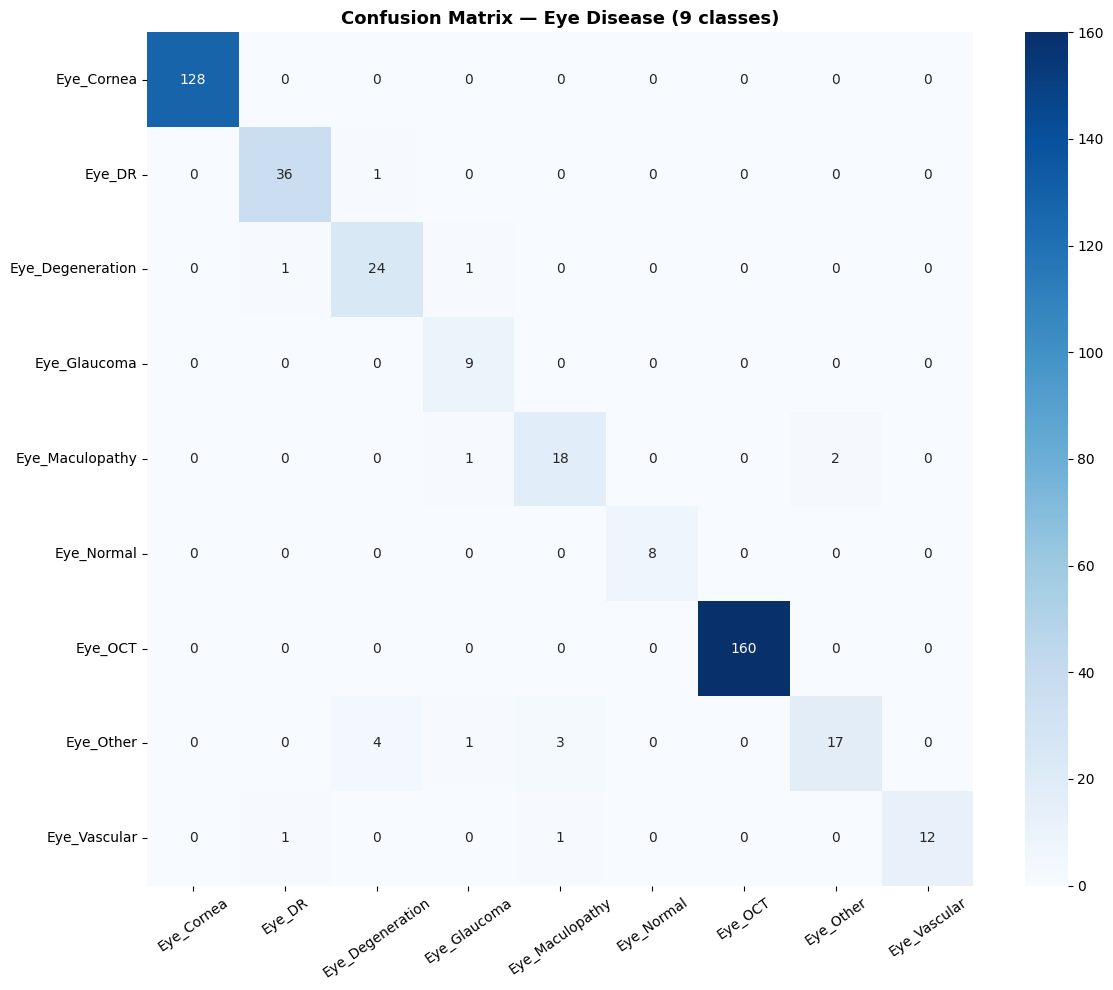

  Saved: eye_model.pth
  Saved: eye_metadata.json
  Saved: eye_cm.png

Eye model done! 9 classes | Best: 96.26%
Classes: ['Eye_Cornea', 'Eye_DR', 'Eye_Degeneration', 'Eye_Glaucoma', 'Eye_Maculopathy', 'Eye_Normal', 'Eye_OCT', 'Eye_Other', 'Eye_Vascular']


In [ ]:
eye_model.load_state_dict(torch.load(BEST_EYE))
eye_model.eval()
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in tqdm(vl_eye_loader, desc="Evaluating"):
        all_p.extend(eye_model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())

print(classification_report(all_l, all_p, target_names=eye_classes))

cm  = confusion_matrix(all_l, all_p)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=eye_classes, yticklabels=eye_classes, ax=ax)
ax.set_title("Confusion Matrix — Eye Disease (9 classes)", fontsize=13, fontweight='bold')
plt.xticks(rotation=35); plt.tight_layout()
plt.savefig("/content/eye_cm.png", dpi=120); plt.show()

# Save model
torch.save(eye_model.state_dict(), "/content/eye_model.pth")

eye_metadata = {
    "model_name"       : "ResNet50 Eye Disease Classifier",
    "num_classes"      : len(eye_classes),
    "classes"          : eye_classes,
    "class_to_idx"     : {c: i for i, c in enumerate(eye_classes)},
    "input_size"       : [224, 224],
    "normalize_mean"   : [0.485, 0.456, 0.406],
    "normalize_std"    : [0.229, 0.224, 0.225],
    "best_val_accuracy": round(best_eye * 100, 2),
    "scan_type"        : "Retinal Fundus Photo + OCT",
    "disease_info": {
        "Eye_Normal"     : {"description": "Healthy retina with no abnormalities", "risk": "None", "treatment": "Annual checkup"},
        "Eye_DR"         : {"description": "Diabetic retinopathy — retinal blood vessel damage from diabetes", "risk": "High", "treatment": "Laser, anti-VEGF injections, glucose control"},
        "Eye_Glaucoma"   : {"description": "Optic nerve damage usually from elevated eye pressure", "risk": "High", "treatment": "Eye drops, laser, surgery"},
        "Eye_Maculopathy": {"description": "Damage to the macula — central vision affected", "risk": "Moderate-High", "treatment": "Anti-VEGF injections, laser"},
        "Eye_Vascular"   : {"description": "Retinal vascular occlusions — blocked blood vessels in retina", "risk": "Moderate-High", "treatment": "Anti-VEGF, observation, treat underlying cause"},
        "Eye_Degeneration": {"description": "Retinal degeneration conditions including RP and pathological myopia", "risk": "Moderate-High", "treatment": "Low vision aids, gene therapy (some), photoprotection"},
        "Eye_OCT"        : {"description": "Conditions identified on OCT: AMD, DME, ERM and others", "risk": "Variable", "treatment": "Depends on specific condition — anti-VEGF, observation"},
        "Eye_Cornea"     : {"description": "Corneal conditions including ulcers", "risk": "Moderate", "treatment": "Antibiotics, antifungals, corneal transplant if severe"},
        "Eye_Other"      : {"description": "Other retinal conditions including ERM, macular hole, disc abnormalities", "risk": "Variable", "treatment": "Surgery (vitrectomy for ERM/MH), observation for others"},
    }
}

with open("/content/eye_metadata.json", "w") as f:
    json.dump(eye_metadata, f, indent=2)

# Save to Drive
for fp in ["/content/eye_model.pth", "/content/eye_metadata.json", "/content/eye_cm.png"]:
    shutil.copy2(fp, os.path.join(SAVE_DIR, os.path.basename(fp)))
    print(f"  Saved: {os.path.basename(fp)}")

print(f"\nEye model done! {len(eye_classes)} classes | Best: {best_eye*100:.2f}%")
print(f"Classes: {eye_classes}")

Skin Model


In [ ]:
import pandas as pd
SKIN_BASE = f"{Base}/skin"
CSV_PATH  = f"{SKIN_BASE}/HAM10000_metadata.csv"
IMG_P1    = f"{SKIN_BASE}/HAM10000_images_part_1"
IMG_P2    = f"{SKIN_BASE}/HAM10000_images_part_2"

print("Skin check:")
print(f"  Part 1: {'YES' if os.path.exists(IMG_P1) else 'NO'}")
print(f"  Part 2: {'YES' if os.path.exists(IMG_P2) else 'NO'}")
print(f"  CSV   : {'YES' if os.path.exists(CSV_PATH) else ' MISSING — download from Kaggle!'}")

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"\n  Rows: {len(df)}")
    print(f"  Cols: {list(df.columns)}")
    print(f"\n  Class distribution:\n{df['dx'].value_counts()}")

Skin check:
  Part 1: YES
  Part 2: YES
  CSV   : YES

  Rows: 10015
  Cols: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

  Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
SKIN_CLASS_NAMES = ["Melanoma","Nevus","Basal_Cell_Ca","Actinic_Keratosis",
                    "Benign_Keratosis","Dermatofibroma","Vascular_Lesion"]
DX_MAP = {"mel":"Melanoma","nv":"Nevus","bcc":"Basal_Cell_Ca",
          "akiec":"Actinic_Keratosis","bkl":"Benign_Keratosis",
          "df":"Dermatofibroma","vasc":"Vascular_Lesion"}

# Build image index from both part folders
img_index = {}
for folder in [IMG_P1, IMG_P2]:
    if not os.path.exists(folder): continue
    for fname in tqdm(os.listdir(folder), desc=f"  Indexing {os.path.basename(folder)}", leave=False):
        img_id = os.path.splitext(fname)[0]
        img_index[img_id] = os.path.join(folder, fname)
print(f"Total images indexed: {len(img_index)}")

df['path']      = df['image_id'].map(img_index)
df['label_name']= df['dx'].map(DX_MAP)
df['label_idx'] = df['label_name'].map({c:i for i,c in enumerate(SKIN_CLASS_NAMES)})
df = df[df['path'].notna() & df['label_name'].notna()].reset_index(drop=True)
print(f"Valid samples: {len(df)}")

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label_idx'], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Total images indexed: 10015
Valid samples: 10015
Train: 8512 | Val: 1503


In [ ]:
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df=dataframe.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]; label=int(row['label_idx'])
        try: img=Image.open(row['path']).convert('RGB')
        except: img=Image.new('RGB',(224,224),0)
        if self.transform: img=self.transform(img)
        return img, label

skin_train_tf = transforms.Compose([
    transforms.Resize((256,256)), transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(30), transforms.ColorJitter(0.3,0.3,0.2,0.1),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
skin_val_tf = transforms.Compose([
    transforms.Resize((256,256)), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

skin_train_ds = SkinDataset(train_df, transform=skin_train_tf)
skin_val_ds   = SkinDataset(val_df,   transform=skin_val_tf)
skin_tr_loader = DataLoader(skin_train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
skin_vl_loader = DataLoader(skin_val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Skin — Train:{len(skin_train_ds)} Val:{len(skin_val_ds)}")


Skin — Train:8512 Val:1503


In [ ]:
skin_counts = df['label_idx'].value_counts().sort_index()
skin_weights = torch.tensor(
    [len(df)/(7*skin_counts[i]) for i in range(7)], dtype=torch.float).to(device)
skin_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for n,p in skin_model.named_parameters():
    if "layer4" not in n and "fc" not in n: p.requires_grad=False
skin_model.fc = nn.Sequential(nn.Dropout(0.5),nn.Linear(skin_model.fc.in_features,512),
                               nn.ReLU(),nn.Dropout(0.3),nn.Linear(512,7))
skin_model = skin_model.to(device)
skin_crit = nn.CrossEntropyLoss(weight=skin_weights)
skin_opt  = optim.AdamW(filter(lambda p:p.requires_grad,skin_model.parameters()),lr=1e-4,weight_decay=1e-4)
skin_sch  = optim.lr_scheduler.CosineAnnealingLR(skin_opt,T_max=10,eta_min=1e-6)

In [ ]:
best_skin=0.0; BEST_SKIN="/content/skin_best.pth"
skin_history={k:[] for k in ["train_loss","val_loss","train_acc","val_acc"]}
print("SKIN — PHASE 1")
for epoch in range(1,11):
    tl,ta=train_epoch(skin_model,skin_tr_loader,skin_crit,skin_opt)
    vl,va=val_epoch(skin_model,skin_vl_loader,skin_crit); skin_sch.step()
    for k,v in zip(skin_history,[tl,vl,ta,va]): skin_history[k].append(v)
    flag=""
    if va>best_skin: best_skin=va; torch.save(skin_model.state_dict(),BEST_SKIN); flag="  ← best"
    print(f"Epoch {epoch:02d}/10 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

SKIN — PHASE 1


  Val  :  49%|████▉     | 23/47 [02:25<02:32,  6.36s/it]

In [ ]:
skin_model.load_state_dict(torch.load(BEST_SKIN))
for p in skin_model.parameters(): p.requires_grad=True
skin_opt2=optim.AdamW(skin_model.parameters(),lr=2e-5,weight_decay=1e-4)
skin_sch2=optim.lr_scheduler.CosineAnnealingLR(skin_opt2,T_max=5,eta_min=1e-7)
print("SKIN — PHASE 2")
for epoch in range(1,6):
    tl,ta=train_epoch(skin_model,skin_tr_loader,skin_crit,skin_opt2)
    vl,va=val_epoch(skin_model,skin_vl_loader,skin_crit); skin_sch2.step()
    for k,v in zip(skin_history,[tl,vl,ta,va]): skin_history[k].append(v)
    flag=""
    if va>best_skin: best_skin=va; torch.save(skin_model.state_dict(),BEST_SKIN); flag="  ← best"
    print(f"Epoch {epoch:02d}/05 | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")
print(f"Best skin: {best_skin*100:.2f}%")

In [ ]:
torch.save(skin_model.state_dict(), "/content/skin_model.pth")
skin_metadata={"model_name":"ResNet50 Skin Disease","num_classes":7,
    "classes":SKIN_CLASS_NAMES,"class_to_idx":{c:i for i,c in enumerate(SKIN_CLASS_NAMES)},
    "input_size":[224,224],"normalize_mean":[0.485,0.456,0.406],"normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_skin*100,2),"scan_type":"Dermoscopy Photo",
    "disease_info":{
        "Melanoma":{"description":"Most dangerous skin cancer","symptoms":["Changing mole","Irregular border","Multiple colors"],"treatment":"Surgery, immunotherapy","risk":"Critical"},
        "Nevus":{"description":"Common benign mole","symptoms":["Round shape","Uniform color"],"treatment":"Monitoring only","risk":"Low"},
        "Basal_Cell_Ca":{"description":"Most common skin cancer","symptoms":["Pearly bump","Bleeding sore"],"treatment":"Surgery, Mohs","risk":"Moderate"},
        "Actinic_Keratosis":{"description":"Sun damage precancerous patch","symptoms":["Rough dry patch","Itching"],"treatment":"Cryotherapy, creams","risk":"Moderate"},
        "Benign_Keratosis":{"description":"Benign waxy skin growth","symptoms":["Waxy stuck-on look","Brown/black color"],"treatment":"None needed","risk":"Low"},
        "Dermatofibroma":{"description":"Benign fibrous nodule","symptoms":["Small firm bump","Dimples when pinched"],"treatment":"None needed","risk":"Very low"},
        "Vascular_Lesion":{"description":"Abnormal blood vessel growth","symptoms":["Red/purple color","Blanches under pressure"],"treatment":"Laser therapy","risk":"Low"},
    }}
with open("/content/skin_metadata.json","w") as f: json.dump(skin_metadata,f,indent=2)
for fp in ["/content/skin_model.pth","/content/skin_metadata.json"]:
    shutil.copy2(fp, os.path.join(SAVE_DIR,os.path.basename(fp))); print(f"  Saved: {os.path.basename(fp)}")
print(f" Skin model done — {best_skin*100:.2f}%")
print("\nALL 3 MODELS TRAINED AND SAVED TO DRIVE!")
print("Files saved:")
print("  brain_model.pth + brain_metadata.json")
print("  eye_model.pth   + eye_metadata.json")
print("  skin_model.pth  + skin_metadata.json")